In [ ]:
import numpy as np

class ShearBuilding:
    """
    Simplified shear tower model:

    - n_stories: Number of floors

    - E: Elastic modulus (Pa)

    - h: Floor height (m)

    - masses: Mass array of each floor, length n_stories (kg)

    - alpha: Scale factor for converting EA/h to equivalent shear stiffness
    """

    def __init__(self, n_stories, E, h, masses, alpha=1.0):
        self.n = n_stories
        self.E = E
        self.h = h
        self.alpha = alpha
        self.masses = np.array(masses, dtype=float)
        if len(self.masses) != self.n:
            raise ValueError("masses length must equal n_stories")

    # ---------- 1. Cross-sectional area -> Shear stiffness per layer ----------
    def areas_to_story_stiffness(self, A):
        """
        A: An array of length n_stories, representing the equivalent cross-sectional area (m^2) of each layer.

        Returns: Shear stiffness k_i (N/m) of each layer.
        """
        A = np.array(A, dtype=float)
        if len(A) != self.n:
            raise ValueError("A length must equal n_stories")

        k = self.alpha * self.E * A / self.h
        return k

    # ---------- 2. Assemble the stiffness matrix K from k. ----------
    def assemble_K(self, k):
        """
        k: An array of length n_stories, representing the shear stiffness of each layer.

        Returns: Stiffness matrix K (n x n)
        """
        k = np.array(k, dtype=float)
        if len(k) != self.n:
            raise ValueError("k length must equal n_stories")

        n = self.n
        K = np.zeros((n, n), dtype=float)

        for i in range(n):
            if i == 0:
                if n == 1:
                    K[i, i] = k[0]
                else:
                    K[i, i] = k[0] + k[1]
                    K[i, i+1] = -k[1]
            elif i == n - 1:
                K[i, i] = k[i]
                K[i, i-1] = -k[i]
            else:
                K[i, i] = k[i] + k[i+1]
                K[i, i-1] = -k[i]
                K[i, i+1] = -k[i+1]

        return K

    # ---------- 3. Mass matrix M ----------
    def assemble_M(self):
        """
        Lumped mass model: diagonal matrix
        """
        return np.diag(self.masses)

    # ---------- 4. Static Analysis ----------
    def static_analysis(self, K, P):
        """
        K: Stiffness matrix (n x n)

        P: Lateral load vector of each story, length n (N)

        Returns:

        - u: Horizontal displacement of each story (n,)

        - story_shear: Shear force of each story (n,) (cumulative from top to bottom)
        """
        P = np.array(P, dtype=float)
        if P.shape != (self.n,):
            raise ValueError("P must have shape (n_stories,)")

        #solving K u = P
        u = np.linalg.solve(K, P)

        # Floor shear force: the accumulated floor load from the top floor downwards.
        story_shear = np.zeros(self.n)
        cumulative = 0.0
        for i in range(self.n-1, -1, -1):
            cumulative += P[i]
            story_shear[i] = cumulative

        return u, story_shear

    # ---------- 5. Modal analysis ----------
    def modal_analysis(self, K, M):
        """
        K, M: Stiffness and mass matrices (n x n)

        Returns:

        - omegas: Sorted array of circular frequencies (rad/s)

        - modes: Corresponding mode shape matrix, one mode per column (n x n)
        """
        # Solving the generalized eigenvalue problem K phi = lambda M phi
        evals, evecs = np.linalg.eig(np.linalg.inv(M) @ K)

        # Only the real part is taken
        evals = np.real(evals)
        evecs = np.real(evecs)

        # Sort by size from smallest to largest
        idx = np.argsort(evals)
        evals = evals[idx]
        evecs = evecs[:, idx]

        # Angular frequency
        omegas = np.sqrt(evals)

        # Unify the mode shape sign (make the top layer degree of freedom positive).
        for i in range(evecs.shape[1]):
            if evecs[-1, i] < 0:
                evecs[:, i] *= -1.0

        return omegas, evecs


In [ ]:
# Build a 6-story shear tower example
n_stories = 6
E = 2.0e11       # Pa
h = 3.0          # m
masses = [2.0e5] * n_stories   # The mass of each layer can be given a reasonable order of magnitude.

building = ShearBuilding(
    n_stories=n_stories,
    E=E,
    h=h,
    masses=masses,
    alpha=1.0
)

def evaluate_design(A, P_per_floor=1e5):
    """
    Input:

    A: An array of cross-sectional areas of length n_stories (m^2)

    Output:

    weight: Total "weight" (approx. sum(A))

    u_top: Top floor horizontal displacement (m)

    V_max: Maximum floor shear force (N)

    omega1: First natural circular frequency (rad/s)
    """
    A = np.array(A, dtype=float)

    # 1) Cross-sectional area -> Stiffness matrix, mass matrix
    k = building.areas_to_story_stiffness(A)
    K = building.assemble_K(k)
    M = building.assemble_M()

    # 2) Static analysis: Each floor has the same lateral load.
    P = np.ones(building.n) * P_per_floor  # N
    u, story_shear = building.static_analysis(K, P)
    u_top = u[-1]
    V_max = np.max(story_shear)

    # 3) Modal analysis
    omegas, modes = building.modal_analysis(K, M)
    omega1 = omegas[0]

    # 4) "Weight" = Sum of cross-sectional area
    weight = np.sum(A)

    return weight, u_top, V_max, omega1


In [ ]:
A_test = [0.02] * n_stories
print(evaluate_design(A_test))


(np.float64(0.12000000000000001), np.float64(0.0015749999999999991), np.float64(600000.0), np.float64(19.683557460969954))


In [ ]:
import pandas as pd

# Cross-section design range
A_min, A_max = 0.01, 0.05   # m^2
N_SAMPLES = 1000            # Sample size

X_list = []
Y_list = []

for _ in range(N_SAMPLES):
    # Randomly generate a set of cross sections within the range.
    A = np.random.uniform(A_min, A_max, size=n_stories)
    weight, u_top, V_max, omega1 = evaluate_design(A)

    X_list.append(A)
    # surrogate Learn only the following three responses
    Y_list.append([u_top, V_max, omega1])

X = np.array(X_list)  # (N, n_stories)
Y = np.array(Y_list)  # (N, 3) -> [u_top, V_max, omega1]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


df_Y = pd.DataFrame(Y, columns=["u_top", "V_max", "omega1"])
print(df_Y.describe())


X shape: (1000, 6)
Y shape: (1000, 3)
             u_top     V_max       omega1
count  1000.000000    1000.0  1000.000000
mean      0.001279  600000.0    22.193866
std       0.000282       0.0     2.545367
min       0.000694  600000.0    15.997504
25%       0.001074  600000.0    20.455904
50%       0.001251  600000.0    22.008992
75%       0.001433  600000.0    23.892914
max       0.002299  600000.0    29.619396


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# devide train / test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)

Y_pred = rf.predict(X_test)

labels = ["u_top", "V_max", "omega1"]

r2_each = r2_score(Y_test, Y_pred, multioutput='raw_values')
mae_each = np.mean(np.abs(Y_test - Y_pred), axis=0)

for name, r2, mae in zip(labels, r2_each, mae_each):
    print(f"{name}: R2 = {r2:.3f}, MAE = {mae:.3e}")


u_top: R2 = 0.923, MAE = 5.376e-05
V_max: R2 = 1.000, MAE = 0.000e+00
omega1: R2 = 0.951, MAE = 4.138e-01


In [ ]:
# Many candidate A's are generated randomly.
N_CAND = 5000
X_cand = np.random.uniform(A_min, A_max, size=(N_CAND, n_stories))

# surrogate Predicted response
Y_cand_pred = rf.predict(X_cand)
u_top_pred  = Y_cand_pred[:, 0]
V_max_pred  = Y_cand_pred[:, 1]
omega1_pred = Y_cand_pred[:, 2]

# weight Use parsed values
weight_true_all = np.sum(X_cand, axis=1)

# setting constraints for example, :
u_max = 0.0025
omega_min = 15.0

feasible_mask = (u_top_pred <= u_max) & (omega1_pred >= omega_min)
feasible_idx = np.where(feasible_mask)[0]

print("feasible designs:", len(feasible_idx))

if len(feasible_idx) > 0:
    best_idx = feasible_idx[np.argmin(weight_true_all[feasible_idx])]
    A_best = X_cand[best_idx]

    print("Best design A_best =", A_best)
    print("surrogate prediction [u_top, V_max, omega1] =", Y_cand_pred[best_idx])
    print("weight (sum A) =", weight_true_all[best_idx])

    # Then verify this optimal solution using a real model.
    weight_true, u_top_true, V_max_true, omega1_true = evaluate_design(A_best)
    print("\nTrue evaluation at best design:")
    print("weight =", weight_true)
    print("u_top  =", u_top_true)
    print("V_max  =", V_max_true)
    print("omega1 =", omega1_true)


feasible designs: 5000
Best design A_best = [0.01617476 0.01518822 0.01456746 0.01836743 0.01312909 0.01412856]
surrogate prediction [u_top, V_max, omega1] = [1.84142660e-03 6.00000000e+05 1.80442649e+01]
weight (sum A) = 0.09155552493798107

True evaluation at best design:
weight = 0.09155552493798107
u_top  = 0.0020417701277968677
V_max  = 600000.0
omega1 = 17.33705818729233


In [ ]:
import numpy as np
import pandas as pd

# Constraints
u_max = 0.0025      # Maximum displacement limit at the top layer (m)
omega_min = 15.0    # Lower limit of the first natural circular frequency (rad/s)


# Number of candidate designs in random search
N_CAND = 5000

# Randomly generate N_CAND groups of cross-sectional areas within the range [A_min, A_max].
X_cand = np.random.uniform(A_min, A_max, size=(N_CAND, n_stories))
print("X_cand shape:", X_cand.shape)


X_cand shape: (5000, 6)


In [ ]:
# Surrogate prediction [u_top, V_max, omega1]
Y_cand_pred = rf.predict(X_cand)
u_top_pred  = Y_cand_pred[:, 0]
V_max_pred  = Y_cand_pred[:, 1]
omega1_pred = Y_cand_pred[:, 2]

# The weight is calculated directly using parsing without surrogate: sum(A)
weight_true_all = np.sum(X_cand, axis=1)   # The sum of A in each row

print("Example: Predicted values ​​for the first 5 candidate designs:")
for i in range(5):
    print(f"cand {i}: weight = {weight_true_all[i]:.4f}, "
          f"u_top_pred = {u_top_pred[i]:.4e}, "
          f"omega1_pred = {omega1_pred[i]:.3f}")


Example: Predicted values ​​for the first 5 candidate designs:
cand 0: weight = 0.1770, u_top_pred = 1.2781e-03, omega1_pred = 21.792
cand 1: weight = 0.1948, u_top_pred = 1.1219e-03, omega1_pred = 23.457
cand 2: weight = 0.1759, u_top_pred = 1.3653e-03, omega1_pred = 21.052
cand 3: weight = 0.2189, u_top_pred = 9.1083e-04, omega1_pred = 26.058
cand 4: weight = 0.1276, u_top_pred = 1.6099e-03, omega1_pred = 19.202


In [ ]:
# Feasibility screening is performed based on surrogate predictions.
feasible_mask = (u_top_pred <= u_max) & (omega1_pred >= omega_min)

feasible_idx = np.where(feasible_mask)[0]
print("Number of feasible designs (by surrogate):", len(feasible_idx))

if len(feasible_idx) == 0:
    print("The current constraints are too strict, and no candidate design can satisfy them. We can appropriately relax u_max or reduce omega_min.")
else:
    # In the "feasible solutions", find the one with the smallest actual weight (sum A).
    best_idx = feasible_idx[np.argmin(weight_true_all[feasible_idx])]

    A_best = X_cand[best_idx]
    weight_best_surrogate = weight_true_all[best_idx]
    u_best_pred  = u_top_pred[best_idx]
    V_best_pred  = V_max_pred[best_idx]
    omega_best_pred = omega1_pred[best_idx]

    print("\n===== Best design (by surrogate + weight) =====")
    print("A_best (m^2) =", A_best)
    print(f"weight (sum A) = {weight_best_surrogate:.4f}")
    print(f"surrogate: u_top = {u_best_pred:.4e}, "
          f"V_max = {V_best_pred:.3e}, "
          f"omega1 = {omega_best_pred:.3f}")


Number of feasible designs (by surrogate): 5000

===== Best design (by surrogate + weight) =====
A_best (m^2) = [0.01331135 0.0127019  0.01533913 0.01260257 0.01744192 0.01760616]
weight (sum A) = 0.0890
surrogate: u_top = 1.9427e-03, V_max = 6.000e+05, omega1 = 17.471


In [ ]:
if len(feasible_idx) > 0:
    # Recalculate the optimal design using a true model.
    weight_true, u_top_true, V_max_true, omega1_true = evaluate_design(A_best)

    print("\n===== True model evaluation at A_best =====")
    print(f"weight_true = {weight_true:.4f}")
    print(f"u_top_true  = {u_top_true:.4e}")
    print(f"V_max_true  = {V_max_true:.3e}")
    print(f"omega1_true = {omega1_true:.3f}")

    print("\n===== Surrogate vs True (errors at A_best) =====")
    print(f"Δweight (true - used) = {weight_true - weight_best_surrogate:.4e}")
    print(f"Δu_top  = {u_top_true  - u_best_pred:.4e}")
    print(f"ΔV_max  = {V_max_true  - V_best_pred:.3e}")
    print(f"Δomega1 = {omega1_true - omega_best_pred:.3f}")



===== True model evaluation at A_best =====
weight_true = 0.0890
u_top_true  = 2.2720e-03
V_max_true  = 6.000e+05
omega1_true = 16.276

===== Surrogate vs True (errors at A_best) =====
Δweight (true - used) = 0.0000e+00
Δu_top  = 3.2929e-04
ΔV_max  = 0.000e+00
Δomega1 = -1.195


In [ ]:
if len(feasible_idx) > 0:
    # Combine all candidate predictions, surrogate predictions, and weights into a single DataFrame.
    cols_A = [f"A{i+1}" for i in range(n_stories)]
    df_cand = pd.DataFrame(X_cand, columns=cols_A)
    df_cand["weight"] = weight_true_all
    df_cand["u_top_pred"] = u_top_pred
    df_cand["V_max_pred"] = V_max_pred
    df_cand["omega1_pred"] = omega1_pred
    df_cand["feasible"] = feasible_mask

    print("/nExample of candidate design dataset (first 5 rows):")
    print(df_cand.head())

    # Just look at the feasible design.：
    df_feasible = df_cand[df_cand["feasible"]].copy()
    print("\nNumber of feasible designs:", len(df_feasible))


/nExample of candidate design dataset (first 5 rows):
         A1        A2        A3        A4        A5        A6    weight  \
0  0.024534  0.018693  0.034271  0.019436  0.037364  0.042710  0.177008   
1  0.023889  0.049446  0.025078  0.019454  0.041161  0.035734  0.194763   
2  0.049763  0.031471  0.010277  0.047416  0.016900  0.020105  0.175932   
3  0.038899  0.047037  0.027139  0.045175  0.030126  0.030479  0.218857   
4  0.026056  0.011720  0.020432  0.016514  0.022479  0.030431  0.127632   

   u_top_pred  V_max_pred  omega1_pred  feasible  
0    0.001278    600000.0    21.792243      True  
1    0.001122    600000.0    23.456690      True  
2    0.001365    600000.0    21.052440      True  
3    0.000911    600000.0    26.057516      True  
4    0.001610    600000.0    19.202123      True  

Number of feasible designs: 5000


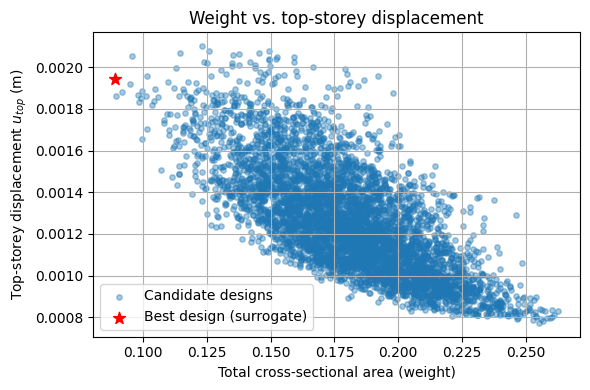

In [ ]:
import matplotlib.pyplot as plt

# Extract the optimal information
best_row = df_cand.iloc[best_idx]
w_best = best_row["weight"]
u_best_pred = best_row["u_top_pred"]

plt.figure(figsize=(6, 4))

# All candidate points (shown in light color)
plt.scatter(df_cand["weight"], df_cand["u_top_pred"],
            s=15, alpha=0.4, label="Candidate designs")

# Optimal surrogate design for highlighting
plt.scatter(w_best, u_best_pred,
            s=80, marker="*", color="red", label="Best design (surrogate)")



plt.xlabel("Total cross-sectional area (weight)")
plt.ylabel("Top-storey displacement $u_{top}$ (m)")
plt.title("Weight vs. top-storey displacement")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


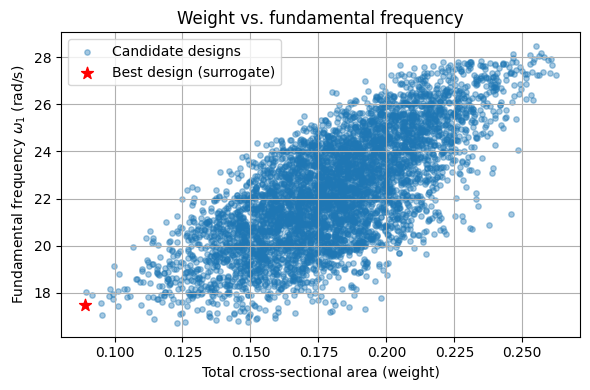

In [ ]:
plt.figure(figsize=(6, 4))

# All candidate points
plt.scatter(df_cand["weight"], df_cand["omega1_pred"],
            s=15, alpha=0.4, label="Candidate designs")

# Optimal surrogate design for highlighting
omega_best_pred = best_row["omega1_pred"]
plt.scatter(w_best, omega_best_pred,
            s=80, marker="*", color="red", label="Best design (surrogate)")



plt.xlabel("Total cross-sectional area (weight)")
plt.ylabel("Fundamental frequency $\\omega_1$ (rad/s)")
plt.title("Weight vs. fundamental frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
